# DQN : Cart Pole(카트폴) 구현 (OpenAI Gym 라이브러리 활용)

In [1]:
from collections import deque
import random
import matplotlib.pyplot as plt
import numpy as np
import gym   # OpenAI Gym for reinforcement learning environments: gym, pygame 설치되어 있어야 합니다.
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def add(self, state, action, reward, next_state, done):
        data = (state, action, reward, next_state, done)
        self.buffer.append(data)

    def __len__(self):
        return len(self.buffer)

    def get_batch(self):
        data = random.sample(self.buffer, self.batch_size)
        state = np.stack([x[0] for x in data])
        action = np.array([x[1] for x in data])
        reward = np.array([x[2] for x in data], dtype=np.float32)
        next_state = np.stack([x[3] for x in data])
        done = np.array([x[4] for x in data], dtype=np.float32)
        return state, action, reward, next_state, done

In [3]:
class QNet(nn.Module):  # 신경망 클래스
    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, 128)
        self.l3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x = self.l3(x)
        return x

In [4]:
class DQNAgent:  # 에이전트 클래스
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.0005
        self.epsilon = 0.1
        self.buffer_size = 10000  # 경험 재생 버퍼 크기
        self.batch_size = 32      # 미니배치 크기
        self.action_size = 2

        self.replay_buffer = ReplayBuffer(self.buffer_size, self.batch_size)
        self.qnet = QNet(self.action_size)
        self.qnet_target = QNet(self.action_size)
        self.optimizer = optim.Adam(self.qnet.parameters(), lr=self.lr)
        self.loss_fn = nn.MSELoss()

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            state_tensor = torch.from_numpy(state.astype(np.float32)).unsqueeze(0)
            with torch.no_grad():
                qs = self.qnet(state_tensor)
                return qs.argmax().item()

    def update(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)
        if len(self.replay_buffer) < self.batch_size:
            return

        state, action, reward, next_state, done = self.replay_buffer.get_batch()
        state = torch.from_numpy(state).float()
        next_state = torch.from_numpy(next_state).float()
        action = torch.from_numpy(action).long()
        reward = torch.from_numpy(reward).float()
        done = torch.from_numpy(done).float()

        qs = self.qnet(state)
        q = qs.gather(1, action.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_qs = self.qnet_target(next_state)
            next_q = next_qs.max(1)[0]
            target = reward + (1 - done) * self.gamma * next_q

        loss = self.loss_fn(q, target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def sync_qnet(self):  # 두 신경망 동기화
        self.qnet_target.load_state_dict(self.qnet.state_dict())


In [5]:
episodes = 200      # 에피소드 수
sync_interval = 20  # 신경망 동기화 주기(20번째 에피소드마다 동기화)
env = gym.make('CartPole-v0', render_mode='rgb_array')
agent = DQNAgent()
reward_history = [] # 에피소드별 보상 기록

for episode in range(episodes):
    state = env.reset()[0]
    done = False
    total_reward = 0

    while not done:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.update(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

    if episode % sync_interval == 0:
        agent.sync_qnet()

    reward_history.append(total_reward)
    if episode % 10 == 0:
        print("episode :{}, total reward : {}".format(episode, total_reward))


c:\Users\David\anaconda3\envs\dl\Lib\site-packages\gym\envs\registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
c:\Users\David\anaconda3\envs\dl\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


episode :0, total reward : 9.0
episode :10, total reward : 9.0
episode :20, total reward : 9.0
episode :30, total reward : 11.0
episode :40, total reward : 10.0
episode :50, total reward : 8.0
episode :60, total reward : 10.0
episode :70, total reward : 11.0
episode :80, total reward : 14.0
episode :90, total reward : 24.0
episode :100, total reward : 37.0
episode :110, total reward : 44.0
episode :120, total reward : 93.0
episode :130, total reward : 132.0
episode :140, total reward : 153.0
episode :150, total reward : 42.0
episode :160, total reward : 200.0
episode :170, total reward : 200.0
episode :180, total reward : 183.0
episode :190, total reward : 200.0


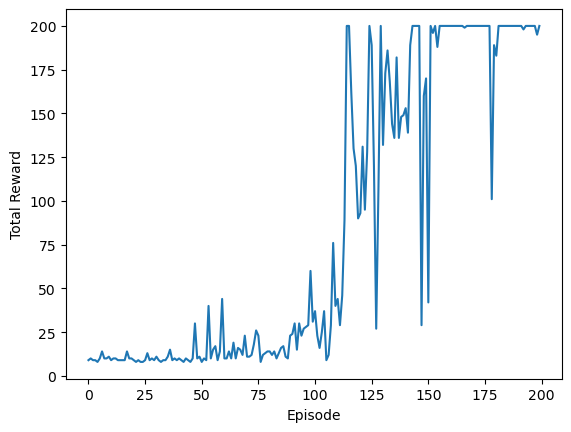

In [6]:
# 에피소드별 보상 총합의 추이
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.plot(range(len(reward_history)), reward_history)
plt.show()

In [7]:
# 학습이 끝난 에이전트에 탐욕 행동을 선택하도록 하여 플레이
agent.epsilon = 0  # 탐욕 정책(무작위로 행동할 확률 ε을 0로 설정)
state = env.reset()[0]
done = False
total_reward = 0

while not done:
    action = agent.get_action(state)
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    state = next_state
    total_reward += reward
    env.render()
print('Total Reward:', total_reward)

Total Reward: 200.0
